In [15]:
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import norm
warnings.filterwarnings("ignore")

## Studi Kasus & Implementasi Python

In [6]:

# Mengatur seed
np.random.seed(42)
n_pelanggan = 200
usia = np.random.randint(20, 65, size=n_pelanggan)

# Variabel kontinu yang akan menjadi dasar variabel buatan
skor_loyalitas = (usia * 10) + np.random.normal(loc=100, scale=50, size=n_pelanggan)
skor_loyalitas = np.clip(skor_loyalitas, 0, 1000)

# Variabel dikotomi sejati
prob_beli = 1 / (1 + np.exp(-(0.08 * (usia - 42))))
beli_premium = np.random.binomial(1, prob_beli)

df = pd.DataFrame({
    'usia': usia,
    'skor_loyalitas': skor_loyalitas,
    'beli_premium': beli_premium
})

# Membuat variabel dikotomi buatan dari 'skor_loyalitas'
ambang_loyalitas = df['skor_loyalitas'].quantile(0.7)
df['loyalitas_tinggi'] = (df['skor_loyalitas'] > ambang_loyalitas).astype(int)

df.head()


,usia,skor_loyalitas,beli_premium,loyalitas_tinggi
0,58,657.911699,1,1
1,48,575.791746,1,0
2,34,501.850804,1,0
3,62,648.676056,1,1
4,27,386.901133,0,0


## Metode 1: Point-Biserial untuk Dikotomi Diskrit (Usia vs. Pembelian Premium)

In [7]:
r_pb, p_value_pb = pointbiserialr(df['usia'], df['beli_premium'])
print(f"Point-Biserial (Usia vs Beli Premium): r = {r_pb:.4f}, p-value = {p_value_pb:.4f}")

# Menghitung R-squared
print(f"R-squared: {r_pb**2:.4f}")

Point-Biserial (Usia vs Beli Premium): r = 0.4459, p-value = 0.0000
R-squared: 0.1988


## Metode 2: Biserial untuk Dikotomi Kontinu (Usia vs. Status Loyalitas Tinggi)

In [16]:
# LANGKAH 1: Hitung korelasi Point-Biserial terlebih dahulu.
pb_corr_df = pg.corr(x=df['usia'], y=df['loyalitas_tinggi'])
r_pb = pb_corr_df['r'].iloc[0]

print(f"Point-Biserial (Usia vs Loyalitas Tinggi): r_pb = {r_pb:.4f}")

# LANGKAH 2: Hitung komponen p, q, dan y untuk rumus konversi.
p = df['loyalitas_tinggi'].mean()
q = 1 - p


# Pertama, cari z-score yang membagi kurva menjadi proporsi p dan q
z_score_cutoff = norm.ppf(1 - p) 
# Kedua, hitung tinggi kurva (PDF) pada z-score tersebut
y = norm.pdf(z_score_cutoff)

print(f"Proporsi p = {p:.4f}, q = {q:.4f}, Ordinat y = {y:.4f}")

# LANGKAH 3: Terapkan rumus konversi untuk mendapatkan korelasi Biserial
r_b = (r_pb * np.sqrt(p * q)) / y

print("-" * 40)
print(f"Hasil Korelasi Biserial (Dihitung Manual): r_b = {r_b:.4f}")

Point-Biserial (Usia vs Loyalitas Tinggi): r_pb = 0.7361
Proporsi p = 0.3000, q = 0.7000, Ordinat y = 0.3477
----------------------------------------
Hasil Korelasi Biserial (Dihitung Manual): r_b = 0.9702


## Visualisasi Perbandingan

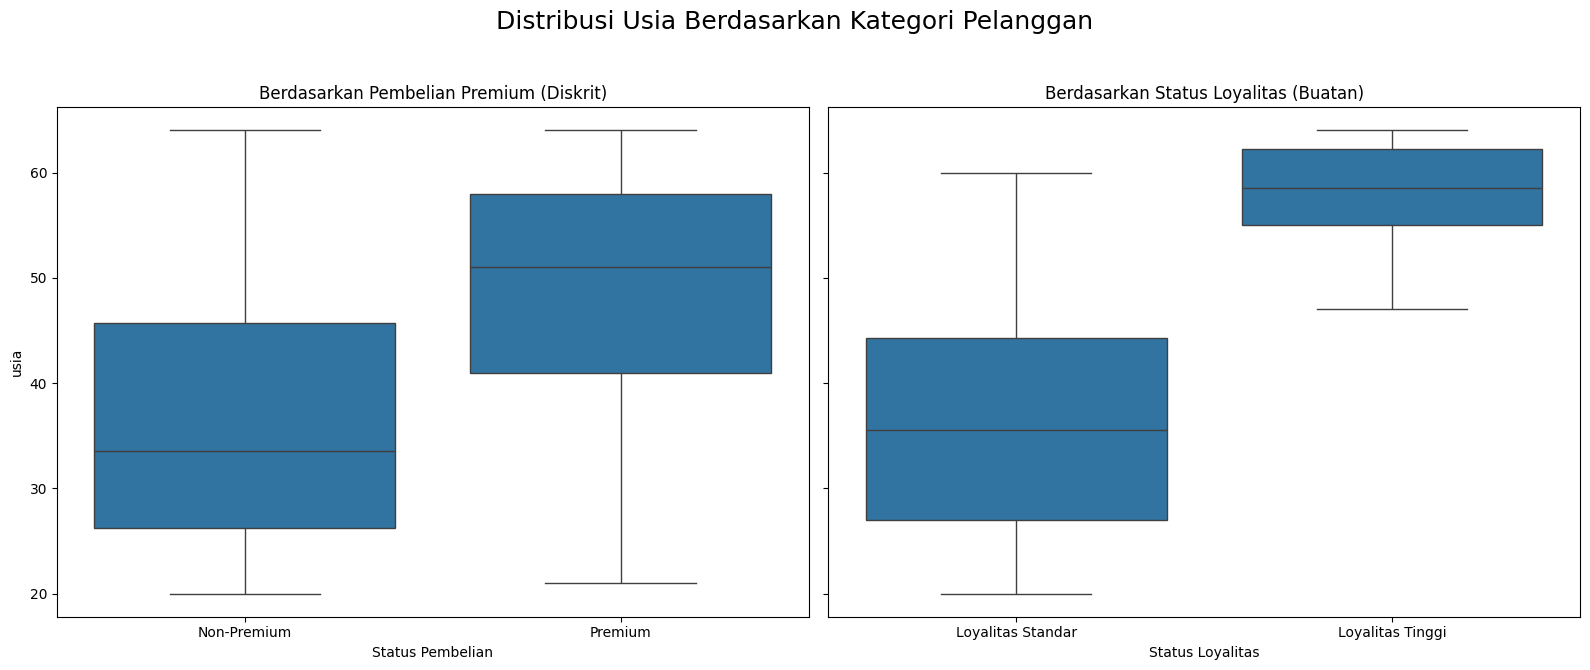

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
fig.suptitle('Distribusi Usia Berdasarkan Kategori Pelanggan', fontsize=18)

# Boxplot untuk perbandingan median dan sebaran
sns.boxplot(ax=axes[0], x='beli_premium', y='usia', data=df)
axes[0].set_title('Berdasarkan Pembelian Premium (Diskrit)')
axes[0].set_xticklabels(['Non-Premium', 'Premium'])
axes[0].set_xlabel('Status Pembelian')

sns.boxplot(ax=axes[1], x='loyalitas_tinggi', y='usia', data=df)
axes[1].set_title('Berdasarkan Status Loyalitas (Buatan)')
axes[1].set_xticklabels(['Loyalitas Standar', 'Loyalitas Tinggi'])
axes[1].set_xlabel('Status Loyalitas')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
